In [85]:
import corner.corner
import numpy as np
import pandas as pd
import corner
import numpy as np
import pandas as pd
import corner


class MCMCResult:
    # TODO riscrivere questa classe che fa proprio merda
    """
    Classe che raccoglie e gestisce i risultati di un fitting MCMC.
    L'utente deve passare un 'sampler' (es. emcee.EnsembleSampler),
    oltre a dati, modello, var_names, ecc.
    La catena viene recuperata internamente (senza dover passare chain o flat_samples).

    Changing 'discard' o 'thin' ricalcola automaticamente le statistiche.
    """

    def __init__(
        self,
        sampler,
        model,
        grid,
        data,
        var_names,
        discard=0,
        thin=1,
        # eventuali parametri aggiuntivi
        message="",
        success=True,
        **kwargs,
    ):
        """
        Parametri
        ---------
        sampler : oggetto di tipo emcee.EnsembleSampler (o simile)
            Da cui recuperare i campioni MCMC.
        model : oggetto/funzione
            Utilizzato per calcolare il modello teorico (ad es. model.call).
        grid : array-like
            Griglia (o x) su cui valutare il modello.
        data : array-like
            Dati sperimentali/osservati.
        var_names : list
            Nomi dei parametri variabili nell'ottimizzazione.
        discard : int
            Numero di step iniziali da scartare (burn-in).
        thin : int
            Thinning factor.
        message : str
            Messaggio opzionale sul risultato.
        success : bool
            Flag di successo o meno.
        kwargs : dict
            Altri attributi opzionali da aggiungere all'oggetto.
        """
        self.sampler = sampler
        self.model = model
        self.grid = grid
        self.data = data
        self.var_names = var_names

        # Parametri per gestire burn-in e thinning
        self._discard = discard
        self._thin = thin

        # Altri attributi (es. stato, message, etc.)
        self.success = success
        self.message = message

        # Inizializziamo alcuni attributi che vogliamo calcolare
        self.best_fit = None
        self.residual = None
        self.chisqr = None
        self.redchi = None
        self.aic = None
        self.bic = None
        self.parameter_summary = None

        # Se vogliamo, possiamo salvare ndata e simili:
        self.ndata = len(data) if hasattr(data, "__len__") else 1
        self.nwalkers = (
            self.sampler.nwalkers if hasattr(self.sampler, "nwalkers") else None
        )
        self.nvarys = len(var_names)

        # Qualsiasi altro attributo presente in kwargs
        for k, v in kwargs.items():
            setattr(self, k, v)

        # Calcola subito le statistiche iniziali
        self.calculate_statistics()

    @property
    def discard(self):
        """Numero di step di burn-in scartati."""
        return self._discard

    @discard.setter
    def discard(self, value):
        self._discard = value
        # Ricalcolo le statistiche ogni volta che discard cambia
        self.calculate_statistics()

    @property
    def thin(self):
        """Fattore di thinning."""
        return self._thin

    @thin.setter
    def thin(self, value):
        self._thin = value
        # Ricalcolo le statistiche ogni volta che thin cambia
        self.calculate_statistics()

    @property
    def chain(self):
        """
        Catena MCMC completa (senza flatten), recuperata dal sampler.
        Dimensioni tipiche: (nsteps, nwalkers, n_params)
        Nota: emcee < 3 aveva dimensioni invertite
        """
        # flat=False per ottenere la catena completa
        return self.sampler.get_chain(
            discard=self._discard, thin=self._thin, flat=False
        )

    @property
    def flatchain(self):
        """
        Catena MCMC "flattened" (2D), recuperata dal sampler.
        Dimensioni tipiche: (nsteps * nwalkers, n_params)
        """
        # flat=True per ottenere la catena appiattita
        return self.sampler.get_chain(discard=self._discard, thin=self._thin, flat=True)

    def calculate_statistics(self):
        """
        Ricalcola best-fit (mediana), residui, chisq, redchi, AIC, BIC,
        e percentili (16, 84) usando i campioni in flatchain.
        """
        # Se non ci sono campioni, esci
        flat = self.flatchain
        if flat is None or len(flat) == 0:
            self.best_fit = None
            self.residual = None
            self.chisqr = 0.0
            self.redchi = np.inf
            self.aic = np.inf
            self.bic = np.inf
            self.parameter_summary = {}
            return

        # Calcolo best fit come mediana
        self.best_fit = np.median(flat, axis=0)  # array di dimensione (n_params,)
        self.best_fit_dict = {
            name: val for name, val in zip(self.var_names, self.best_fit)
        }
        # Calcolo residui con i parametri best-fit (usando self.model)
        # Assumiamo che la model.call(grid, *params) sia la sintassi
        model_output = self.model.call(self.grid, *self.best_fit)
        # Ravel per sicurezza
        self.residual = (self.data - model_output).ravel()

        # Calcolo chisqr
        self.chisqr = float((self.residual**2).sum())

        # Gradi di libertà e chi-quadro ridotto
        # (eventualmente potremmo salvare un attributo self.nfree = self.ndata - self.nvarys)
        nfree = self.ndata - self.nvarys
        if nfree > 0:
            self.redchi = self.chisqr / nfree
        else:
            self.redchi = np.inf

        # Calcolo AIC e BIC usando chisqr come -2 ln L
        eps = 1e-250
        chisqr_valid = max(self.chisqr, eps * self.ndata)
        _neg2_log_likel = self.ndata * np.log(chisqr_valid / self.ndata)
        self.aic = _neg2_log_likel + 2 * self.nvarys
        if self.ndata > 0:
            self.bic = _neg2_log_likel + np.log(self.ndata) * self.nvarys
        else:
            self.bic = np.inf

        # Calcolo dei percentili 16, 84 e mediana per ciascun parametro
        self.parameter_summary = {}
        for i, pname in enumerate(self.var_names):
            param_samples = flat[:, i]
            p16 = np.percentile(param_samples, 16)
            p84 = np.percentile(param_samples, 84)
            med = np.median(param_samples)
            self.parameter_summary[pname] = {"median": med, "p16": p16, "p84": p84}

    def plot_corner(self):
        """
        Esempio di funzione per generare il corner plot.
        """
        flat = self.flatchain
        if flat is None or len(flat) == 0:
            print("Nessun campione per il corner plot.")
            return
        corner.corner(flat, labels=self.var_names)

    def __repr__(self):
        return (
            f"<MCMCResult success={self.success} chisqr={self.chisqr:.4g} "
            f"redchi={self.redchi:.4g} ndata={self.ndata} nvarys={self.nvarys} "
            f"discard={self.discard} thin={self.thin}>"
        )

    def __str__(self):
        lines = [
            "=== MCMCResult ===",
            f"    success   = {self.success}",
            f"    message   = {self.message}",
            f"    discard   = {self.discard}",
            f"    thin      = {self.thin}",
            f"    ndata     = {self.ndata}",
            f"    nvarys    = {self.nvarys}",
            f"    chisqr    = {self.chisqr:.4g}",
            f"    redchi    = {self.redchi:.4g}",
            f"    aic       = {self.aic:.4g}",
            f"    bic       = {self.bic:.4g}",
        ]
        # Se abbiamo un best_fit
        if self.best_fit is not None:
            lines.append("    best_fit:")
            for pname, val in zip(self.var_names, self.best_fit):
                lines.append(f"  {pname} = {val:.4g}  {self.model[pname].description}")

        # Se abbiamo summary percentile
        if self.parameter_summary:
            lines.append("\n    Parameter summary (median [p16, p84]):")
            for pname, stats in self.parameter_summary.items():
                lines.append(
                    f"        {pname:15s}: {stats['median']:.4g} "
                    f"[{stats['p16']:.4g}, {stats['p84']:.4g}]"
                )

        return "\n".join(lines)


In [86]:
a = np.array([[1],[2]])
b = np.array([*a])
b.shape

(2, 1)

In [113]:
from typing import Iterable, Union, Dict, Optional
import emcee
import corner
from model import Model

from functools import singledispatchmethod



class MCMC:
    def __init__(self, model, **kwargs):
        # what kwargs?
        self._model = model

    @property
    def model(self) -> Model:
        return self._model

    @model.setter
    def model(self, value) -> None:
        if not isinstance(value, Model):
            raise TypeError("Model must be instance of Model class")

    @property
    def var_names(self) -> list[str]:
        return [key for key in self.model.parameters_keys if self.model[key].is_free]

    def logprior(self, theta: np.ndarray) -> float:
        """
        Calcola il log-prior per i parametri `theta`.

        Il prior è zero se tutti i parametri rientrano nei rispettivi bounds,
        altrimenti ritorna `-np.inf`.

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.

        Returns
        -------
        float
            Il valore della log-prior.
        """
        return sum(param(val) for param, val in zip(self.model.free_parameters, theta))

    def loglike(
        self,
        theta: np.ndarray,
        xdata: Union[list, np.ndarray],
        ydata: Union[list, np.ndarray],
        yerr: Union[list, np.ndarray],
    ) -> float:
        """
        Calcola la log-likelihood dati i dati e il modello,
        assumendo errori gaussiani indipendenti.

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.
        xdata : array-like
            Dati indipendenti (es. valori di ascissa).
        ydata : array-like
            Dati osservati (es. valori di ordinata).
        yerr : array-like
            Incertezze (errore standard) associate ai dati osservati.

        Returns
        -------
        float
            Valore della log-likelihood.
        """
        # Calcolo del modello
        #

        ymodel = self.model.call(xdata, *theta)

        return -0.5 * np.nansum(((ydata - ymodel) / yerr) ** 2)

    def log_probability(
        self,
        theta: np.ndarray,
        xdata: Union[list, np.ndarray],
        ydata: Union[list, np.ndarray],
        yerr: Union[list, np.ndarray],
    ) -> float:
        """
        Calcola la log-probability (somma di log-prior e log-likelihood).

        Parameters
        ----------
        theta : np.ndarray
            Valori correnti dei parametri del modello.
        xdata : array-like
            Dati indipendenti.
        ydata : array-like
            Dati osservati.
        yerr : array-like
            Incertezze (errore standard) associate ai dati osservati.

        Returns
        -------
        float
            Valore della log-probabilità (log-prior + log-likelihood).
        """
        lp = self.logprior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + self.loglike(theta, xdata, ydata, yerr)

    def _check_prior_conflicts(self, theta0: np.ndarray | list):
        for i, (value, param) in enumerate(zip(theta0, self.model.free_parameters)):
            pval = param.prior(value)
            if not np.isfinite(pval):
                raise ValueError(
                    f"Initial value {value} for param {self.var_names[i]} conflicts with is prior!"
                )
            if value < param.bounds[0] or value > param.bounds[1]:
                raise ValueError(
                    f"Initial value {value} for param {self.var_names[i]} conflicts with its bounds!"
                )

    def _check_grid_conflicts(self, grid: np.ndarray):
        if grid.shape[0] != len(self.model.grid_variables):
            raise ValueError(
                f"Grid number of elements {grid.ndim} do not match model number of elements {len(self.model.grid_variables)}"
            )

    def _check_data_conflicts(self, grid, theta0, data):
        # better to use try: with custom model errors
        assert grid.shape[0] == len(self.model.grid_variables)
        model_output = self.model.call(grid, *theta0)
        if np.shape(model_output) != np.shape(data):
            raise ValueError(
                f"Model incompatibility between output {np.shape(model_output)}  and data {np.shape(data)}"
            )

    def _check_burnin_conflicts(self, burn_in):
        if burn_in < 0:
            raise ValueError("numver of burn-in step must be >= 0 or None")

    @singledispatchmethod
    def _check_type_grid(self, grid):
        # see if number of elements match expected ndim
        raise TypeError("provided grid elements must be lists or numpy arrays")

    @_check_type_grid.register
    def _(self, grid: list) -> np.ndarray:
        grid_array = np.array([*grid])
        if grid_array.ndim == 1:
            grid_array = np.array([grid_array])  # model.call require [x,y] or just [x]
        self._check_grid_conflicts(grid_array)
        return grid_array

    @_check_type_grid.register
    def _(self, grid: np.ndarray) -> np.ndarray:
        if grid.ndim == 1:
            grid_array = np.array([grid])
        else:
            grid_array = grid
        self._check_grid_conflicts(grid_array)
        return grid_array

    @singledispatchmethod
    def _check_type_theta0(self, theta0):
        """check the type of theta0 and prepare it for the fit"""
        raise TypeError("Unsupported type for theta0")

    @_check_type_theta0.register
    def _(self, theta0: list) -> np.ndarray:
        # theta0 is a list, loop and check values and or prior
        if len(theta0) != self.model.n_free_parameters:
            raise ValueError(
                "Dimension miss match! len of initial guess must be equal to paramater space number od dimensions!"
            )
        return np.array([*theta0])

    @_check_type_theta0.register
    def _(self, theta0: dict) -> None:
        # theta0 is a dict, see if key-values are ok
        tmp = []
        for key, value in theta0.items():
            if key not in self.model:
                raise ValueError(f"unknown parameter: {key}")
            if not self.model[key].is_free:
                raise ValueError(f"Parameter {key} is not free")
            
        for key in self.model.parameters_keys:
            if key in theta0:
                tmp.append(theta0[key])
            else:
                tmp.append(self.model[key].value)
        print(tmp)
        return self._check_type_theta0(tmp)

    @_check_type_theta0.register
    def _(self, theta0: np.ndarray) -> np.ndarray:
        self._check_prior_conflicts(theta0)
        return theta0

    def _emcee_positions(
        self,
        theta0: np.ndarray,
        nwalkers: int,
        dispersion: float,
    ) -> np.ndarray:
        """
        Genera una matrice di posizioni iniziali per emcee con dispersione
        del 10% rispetto ai parametri iniziali. I punti fuori dai bound
        specificati vengono rigenerati.

        Parameters
        ----------
        theta0 : np.ndarray
            Posizione iniziale dei parametri, array di forma (ndim,).
        nwalkers : int
            Numero di walkers per emcee.
        bounds : list of tuple
            Lista di tuple (lower_bound, upper_bound) per ciascun parametro.

        Returns
        -------
        np.ndarray
            Array di forma (nwalkers, ndim) contenente le posizioni iniziali
            dei walkers.
        """
        ndim = len(theta0)
        pos = np.zeros((nwalkers, ndim))

        if dispersion < 0 or dispersion > 1:
            raise ValueError("Initial points dispersion must be > 0 and < 1")

        def generate_valid_position() -> np.ndarray:
            while True:
                # Genera una posizione con dispersione casuale (10%)
                candidate = theta0 + dispersion * np.abs(theta0) * (
                    2 * np.random.rand(ndim) - 1
                )
                # Controlla se tutti i parametri rispettano i bound
                if all(
                    np.isfinite(p.prior(p.value)) for p in self.model.free_parameters
                ):
                    return candidate

        # Popola l'array con posizioni valide per ciascun walker
        for i in range(nwalkers):
            pos[i] = generate_valid_position()

        return pos

    def fit(
        self,
        *,
        data,
        grid=None,
        theta0=None,
        error=None,
        nwalkers=32,
        nsteps=1000,
        dispersion=0.1,
        burn_in=None,
        pool=None,
        progress=True,
        optimize=True,
        thin=1,
        **kwargs,
    ):
        # check for correct initial grid:
        if grid is not None:
            grid = self._check_type_grid(grid)
        else:
            tmp_grid = []
            grid_check = self.model.grid_variables
            for key in grid_check:
                if key not in kwargs:
                    raise ValueError(f"Expected grid variable {key} as keyboard args")
                
                tmp_grid.append(kwargs[key])
                kwargs.pop(key)
            grid = self._check_type_grid(tmp_grid)

        # control theta0
        if theta0 is None:
            theta0 = [p.value for p in self.model.free_parameters]

        initial_point = self._check_type_theta0(theta0)  # np array of shape(n_varys, 1)

        # controll data compatibility
        if error is None:
            error = np.ones(np.shape(data))  # stupid workaround
        self._check_data_conflicts(grid=grid, theta0=initial_point, data=data)
        # TODO: add support for multiple data dimension

        # now ready to setup the sampler
        # setup the sampler and add burn-in support
        sampler = emcee.EnsembleSampler(
            nwalkers=nwalkers,
            ndim=len(self.model.free_parameters),
            log_prob_fn=self.log_probability,  # to write
            args=(grid, data, error),  # to write
            pool=pool,
            **kwargs,
        )

        # optimization step to guess the initial point
        if optimize:
            from scipy.optimize import minimize

            initial_point = minimize(
                lambda xtheta, xgrid, xdata, err: -self.log_probability(
                    xtheta, xgrid, xdata, err
                ),
                x0=initial_point,
                args=(grid, data, error),
                bounds=[p.bounds for p in self.model if p.is_free],
            )
            if initial_point.success:
                print(f"Optimization done, initial position is {initial_point.x}")
                initial_point = initial_point.x
            else:
                print("initial optimization failed")

        initial_positions = self._emcee_positions(initial_point, nwalkers, dispersion)

        # setu the burn-in phase
        if burn_in is not None:
            self._check_burnin_conflicts(burn_in)
            pos, _, _ = sampler.run_mcmc(initial_positions, burn_in, progress=progress)
            # reset the sampler
            sampler.reset()
            #print(pos.shape)
            #initial_positions = self._emcee_positions(pos, nwalkers, dispersion)
            initial_positions = pos

        # now run the sampler
        pos, prob, state = sampler.run_mcmc(
            initial_positions, nsteps, progress=progress
        )

        # to resolve
        result = MCMCResult(
            sampler=sampler,
            model=self.model,  # ad esempio un oggetto con metodo .call
            grid=grid,
            data=data,
            var_names=self.var_names,  # lista dei nomi
            discard=burn_in,  # burn-in
            thin=thin,  # thinning
            success=True,
            message="MCMC sampling completed successfully",
        )
        return result


In [88]:
from model import Model
import matplotlib.pyplot as plt

def line(x,a,b):
    return a*x + b

line_model = Model.wrap(line, grid_variables=["x"])
print(line_model)

MODEL NAME: SimpleModel
FREE PARAMS: 2
GRID VARIABLES: ['x']
N-DIM: 1
----------------------------------------------------------------------------------------------------
  INDEX  NAME      VALUE  IS-FREE    PRIOR               DESCR
      0  a             1  Yes        Uniform(-inf, inf)
      1  b             1  Yes        Uniform(-inf, inf)


Text(0, 0.5, 'y')

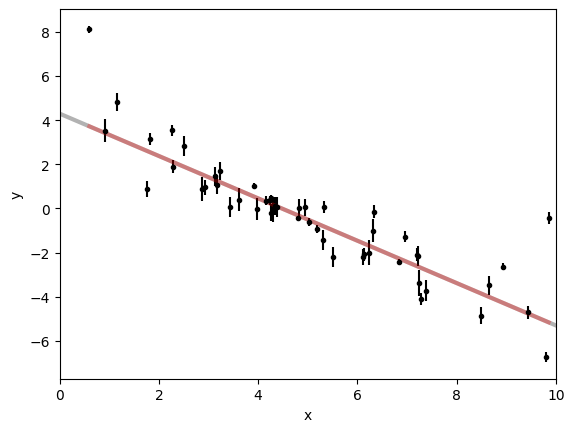

In [89]:


np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = line(x, m_true,b_true)
y_model = line_model(x, a=m_true, b=b_true)

y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.plot(x, y_model, "r", alpha=0.3, lw=3)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

In [90]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    #model = line_model.call([x], *theta[:-1])
    #log_f = theta[-1]
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

In [91]:
pos = np.array([-1.003,4.528,0.454]) + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape


sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x, y, yerr))
res =  sampler.run_mcmc(pos, 5000, progress=True)


100%|██████████| 5000/5000 [00:06<00:00, 831.40it/s]


(10432, 3)


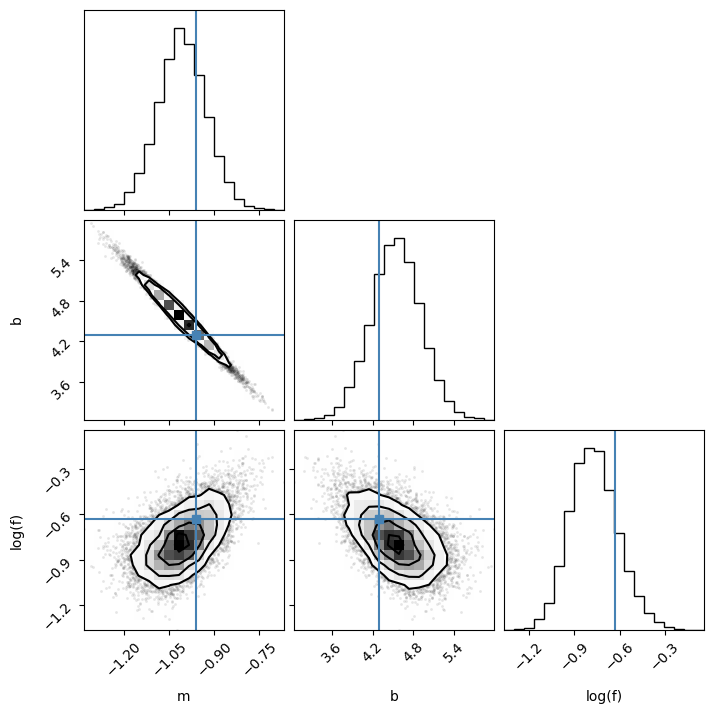

In [92]:
import corner
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)
labels = ["m", "b", "log(f)"]

fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)


In [93]:
wrapper = MCMC(line_model)

result = wrapper.fit(#grid = np.array([x]),
            grid = x,
            data = y,
            error = yerr,
            theta0 = None,
            nwalkers=32,
            burn_in=100,
            #ndim=2
            )

Optimization done, initial position is [-1.10407571  5.44055564]


100%|██████████| 1000/1000 [00:03<00:00, 258.77it/s]


In [94]:
print(result)

=== MCMCResult ===
    success   = True
    message   = MCMC sampling completed successfully
    discard   = 100
    thin      = 1
    ndata     = 50
    nvarys    = 2
    chisqr    = 77.55
    redchi    = 1.616
    aic       = 25.94
    bic       = 29.77
    best_fit:
  a = -1.102  
  b = 5.433  

    Parameter summary (median [p16, p84]):
        a              : -1.102 [-1.118, -1.087]
        b              : 5.433 [5.343, 5.524]


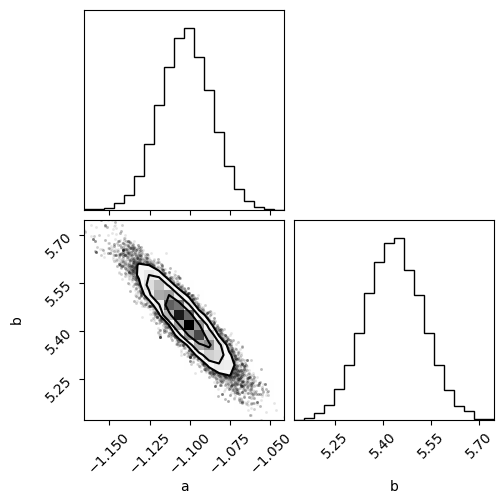

In [95]:


fig = corner.corner(result.flatchain, labels = result.var_names)

Text(0, 0.5, 'y')

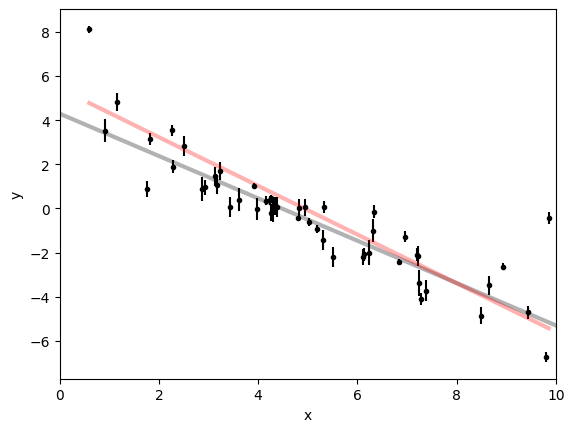

In [96]:

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.plot(x, line_model(x, **result.best_fit_dict), "r", alpha=0.3, lw=3)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")


In [97]:
import numpy as np
from model import Model

def line(x, a, b):
    return a * x + b

def gaussian(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))

gaus = Model.wrap(gaussian, grid_variables=['x'], name = 'Gaussian')

line1 = Model.wrap(line, grid_variables=['x'], name='line')

cmodel = (gaus + gaus) + line1

cmodel.set_parameters_values(
    mu_0 =5.2,
    sigma_1 = 1.2,
    A_1 = 10,
    a_2 = 1.2,
    sigma_0 = .3,
    A_0 = 13.4,
    mu_1 = 2.5,
    b_2 = 0.01
)

print(cmodel)
cmodel.print_tree()

COMPOSITE MODEL NAME: CompositeModel
CONTAINED MODELS: Gaussian, Gaussian, line
GRID VARIABLES: ['x']
LOGIC: ((Gaussian [0] + Gaussian [1]) + line [2])
FREE PARAMS: 8
------------------------------------------------------------
  INDEX  NAME       VALUE  IS-FREE    PRIOR               DESCR
      0  mu_0        2.5   Yes        Uniform(-inf, inf)
      1  sigma_0     0.3   Yes        Uniform(-inf, inf)
      2  A_0        13.4   Yes        Uniform(-inf, inf)
      3  mu_1        2.5   Yes        Uniform(-inf, inf)
      4  sigma_1     0.3   Yes        Uniform(-inf, inf)
      5  A_1        13.4   Yes        Uniform(-inf, inf)
      6  a_2         1.2   Yes        Uniform(-inf, inf)
      7  b_2         0.01  Yes        Uniform(-inf, inf)
Composite(op='+')
    |-- Composite(op='+')
    |   |-- Gaussian
    |   `-- Gaussian
    `-- line


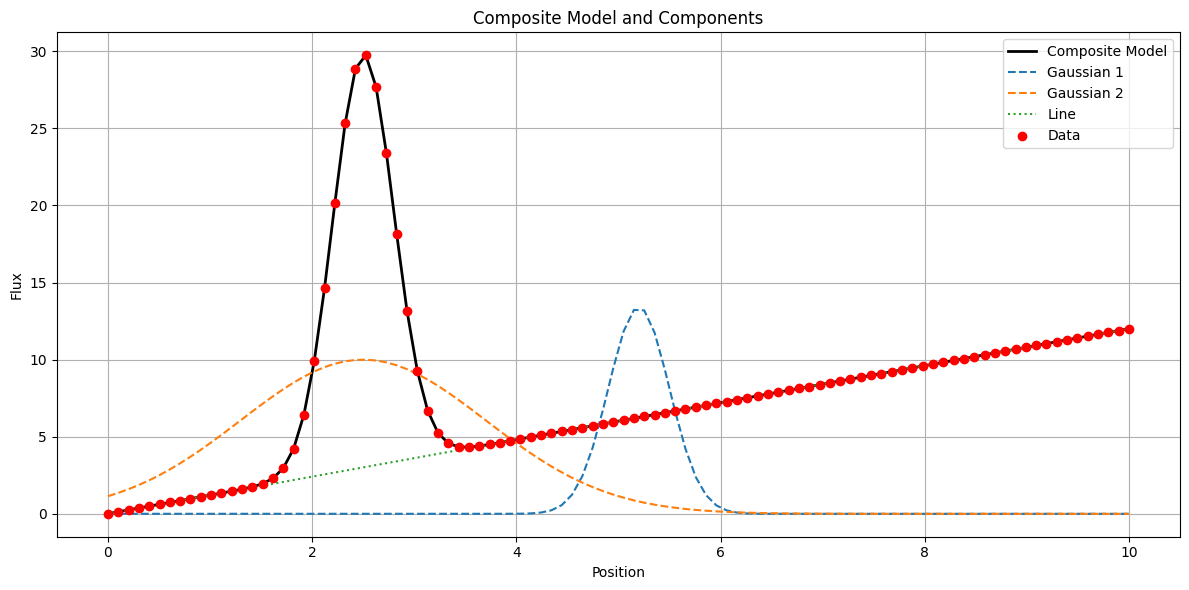

In [98]:
import matplotlib.pyplot as plt
# Define the x range
X = np.linspace(0, 10, 100)

# Evaluate the composite model and its components
y = cmodel.call([X], *cmodel.parameters_values)

gaus_0 = gaus.copy()
gaus_0.set_parameters_values(mu=5.2, sigma=0.3, A=13.4)
gaus_1 = gaus.copy()
gaus_1.set_parameters_values(mu=2.5, sigma=1.2, A=10)
line1.set_parameters_values(a=1.2, b=0.01)

y_gaus_0 = gaus_0.call([X], *gaus_0.parameters_values)
y_gaus_1 = gaus_1.call([X], *gaus_1.parameters_values)
y_line1 = line1.call([X], *line1.parameters_values)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(X, y, "k-", label="Composite Model", linewidth=2)
plt.plot(X, y_gaus_0, "--", label="Gaussian 1", linewidth=1.5)
plt.plot(X, y_gaus_1, "--", label="Gaussian 2", linewidth=1.5)
plt.plot(X, y_line1, ":", label="Line", linewidth=1.5)
plt.scatter(X, y, color="red", label="Data", zorder=5)

plt.title("Composite Model and Components")
plt.xlabel("Position")
plt.ylabel("Flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [114]:
#cmodel.freeze_parameters('A_0')
opt = MCMC(cmodel)

result = opt.fit(#grid = np.array([X]),  
                 x = X,
                 #grid=X,
                 data = y,
                 error = y/100,
                 theta0={'mu_0':2, "A_0":1},
                 #discard = 100,
                 dispersion=0.2,
                 nsteps=1000,
                 optimize=True,
                 burn_in=100
                 )

[2, 0.3, 1, 2.5, 0.3, 13.4, 1.2, 0.01]
Optimization done, initial position is [2.53886510e+00 2.98632392e-01 6.30692325e+00 2.48810949e+00
 2.99410074e-01 2.05621884e+01 1.20000120e+00 9.99996954e-03]


100%|██████████| 1000/1000 [00:08<00:00, 119.98it/s]


In [115]:
print(result)
#print(cmodel)


=== MCMCResult ===
    success   = True
    message   = MCMC sampling completed successfully
    discard   = 100
    thin      = 1
    ndata     = 100
    nvarys    = 8
    chisqr    = 0.2517
    redchi    = 0.002736
    aic       = -582.5
    bic       = -561.6
    best_fit:
  mu_0 = 2.528  
  sigma_0 = 0.2955  
  A_0 = 6.956  
  mu_1 = 2.494  
  sigma_1 = 0.2991  
  A_1 = 20.07  
  a_2 = 1.2  
  b_2 = 0.009983  

    Parameter summary (median [p16, p84]):
        mu_0           : 2.528 [2.479, 2.602]
        sigma_0        : 0.2955 [0.283, 0.3054]
        A_0            : 6.956 [2.113, 11.06]
        mu_1           : 2.494 [2.467, 2.507]
        sigma_1        : 0.2991 [0.295, 0.3025]
        A_1            : 20.07 [15.93, 24.92]
        a_2            : 1.2 [1.198, 1.201]
        b_2            : 0.009983 [0.009891, 0.01009]


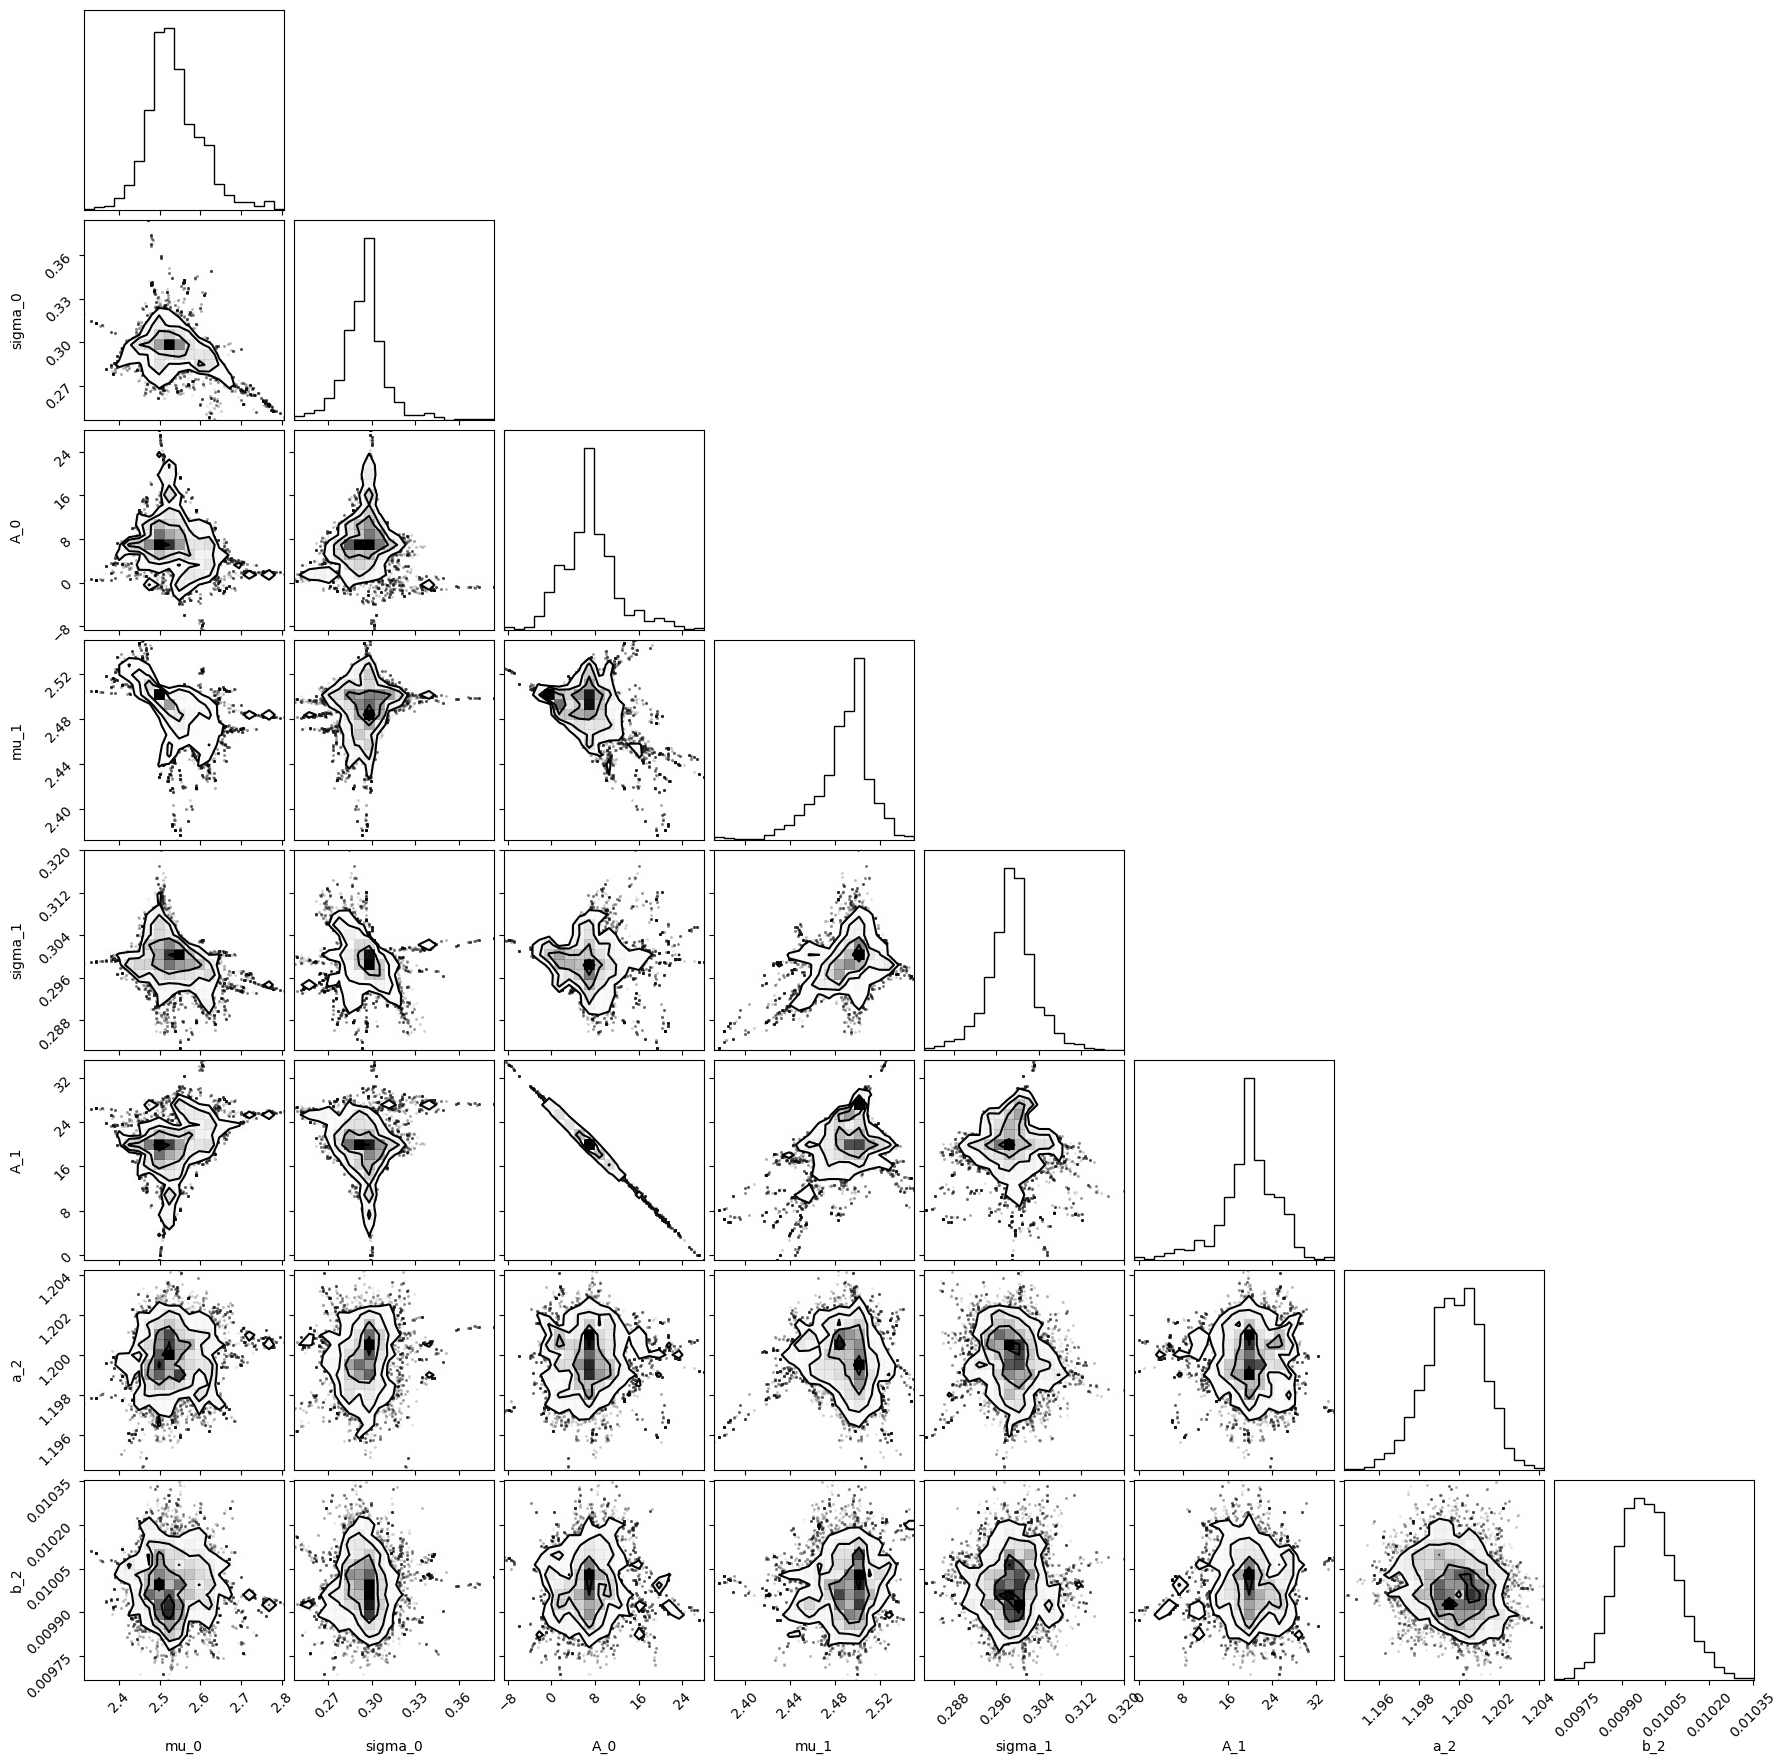

In [116]:
fig =corner.corner(result.flatchain, labels=result.var_names)